<div align="center">

# Financial Inclusion in Malawi
## Executive Summary — Global Findex 2024 Analysis

<br>

| | |
|---|---|
| **Author** | Brian Thuwala |
| **Date** | February 2026 |
| **Dataset** | World Bank Global Findex 2024 — Malawi Microdata |
| **Sample** | 1,000 nationally representative adults (15+) |
| **Methodology** | Survey-weighted descriptive & logistic regression analysis |

</div>

---

### 📋 Purpose

This executive summary distills findings from a four-notebook analytical pipeline examining financial inclusion in Malawi using the World Bank Global Findex 2024 microdata. It is designed for **policymakers**, **development practitioners**, and **researchers** seeking actionable, evidence-based insights.

### 🎯 Research Questions

| # | Question | Notebook |
|:-:|----------|:--------:|
| 1 | What is the current state of financial inclusion in Malawi? | [NB 02](02_descriptive_analysis.ipynb) |
| 2 | How does access vary by gender, residence, income, and education? | [NB 02](02_descriptive_analysis.ipynb) |
| 3 | What are the main barriers preventing account ownership? | [NB 03](03_barriers_analysis.ipynb) |
| 4 | Which barriers have the strongest statistical impact on exclusion? | [NB 04](04_from_barriers_to_policy.ipynb) |
| 5 | What policy interventions would be most effective? | [NB 04](04_from_barriers_to_policy.ipynb) |

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SETUP: Professional Theme, Data Loading & Helper Functions
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ─── COLOR PALETTE (inspired by The Economist / FT) ────────────
COLORS = {
    'primary':      '#1B4F72',   # Deep navy
    'secondary':    '#2E86C1',   # Bright blue
    'accent':       '#E67E22',   # Warm orange
    'success':      '#27AE60',   # Green
    'danger':       '#C0392B',   # Red
    'warning':      '#F39C12',   # Gold
    'light':        '#F8F9FA',   # Near-white
    'dark':         '#2C3E50',   # Dark charcoal
    'muted':        '#5D6D7E',   # Soft grey
    'bg':           '#FAFBFC',   # Background
    'grid':         '#E8ECF0',   # Grid lines
    'text':         '#2C3E50',   # Body text
    'mobile':       '#2ECC71',   # Mobile money green
    'bank':         '#3498DB',   # Bank blue
    'total':        '#1B4F72',   # Total navy
}

PALETTE_SEQ = ['#1B4F72', '#2E86C1', '#5DADE2', '#85C1E9', '#AED6F1']
PALETTE_DIV = ['#C0392B', '#E74C3C', '#F8F9FA', '#2E86C1', '#1B4F72']
PALETTE_CAT = ['#1B4F72', '#2E86C1', '#27AE60', '#E67E22', '#C0392B', '#8E44AD', '#F39C12']

# ─── MATPLOTLIB THEME ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':     COLORS['bg'],
    'axes.facecolor':       COLORS['bg'],
    'axes.edgecolor':       COLORS['grid'],
    'axes.labelcolor':      COLORS['text'],
    'axes.titlecolor':      COLORS['text'],
    'text.color':           COLORS['text'],
    'xtick.color':          COLORS['muted'],
    'ytick.color':          COLORS['muted'],
    'grid.color':           COLORS['grid'],
    'grid.alpha':           0.6,
    'grid.linewidth':       0.5,
    'figure.figsize':       (14, 7),
    'font.size':            11,
    'axes.titlesize':       16,
    'axes.labelsize':       12,
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,
    'legend.fontsize':      10,
    'figure.titlesize':     18,
    'font.family':          'sans-serif',
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.titleweight':     'bold',
    'axes.labelweight':     'medium',
    'figure.dpi':           120,
    'savefig.dpi':          200,
    'savefig.bbox':         'tight',
})

# ─── DATA LOADING ─────────────────────────────────────────────────────────────
df = pd.read_csv("../data/raw/Findex_Microdata_2025_updateMalawi.csv")

# ─── HELPER FUNCTIONS ─────────────────────────────────────────────────────────
def weighted_mean(series, weights):
    """Calculate weighted mean excluding missing values."""
    valid = series.notna() & weights.notna()
    if valid.sum() == 0:
        return np.nan
    return np.average(series[valid], weights=weights[valid])

def weighted_pct(series, weights, value=1):
    """Weighted percentage for binary (0/1) or coded variable."""
    valid = series.notna() & weights.notna()
    if valid.sum() == 0:
        return np.nan
    binary = (series[valid] == value).astype(float)
    return np.average(binary, weights=weights[valid]) * 100

def fmt_pct(val):
    """Format percentage with one decimal."""
    return f"{val:.1f}%"

def add_source_note(fig, extra=""):
    """Add professional source attribution."""
    txt = "Source: World Bank Global Findex 2024 — Malawi Microdata (n = 1,000; survey-weighted estimates)"
    if extra:
        txt += f"\n{extra}"
    fig.text(0.02, -0.02, txt, fontsize=10, color=COLORS['muted'],
             fontstyle='italic', ha='left', va='top')

def styled_table(data, title="", highlight_col=None, highlight_thresh=None,
                 bar_col=None, precision=1, caption=""):
    """Return a publication-quality styled pandas DataFrame."""
    styler = data.style.set_caption(caption or title)

    # CSS for professional look
    styler = styler.set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size', '14px'), ('font-weight', 'bold'),
            ('color', COLORS['primary']), ('text-align', 'left'),
            ('padding-bottom', '8px')]},
        {'selector': 'thead th', 'props': [
            ('background-color', COLORS['primary']), ('color', 'white'),
            ('font-weight', 'bold'), ('text-align', 'center'),
            ('padding', '8px 12px'), ('border-bottom', f'2px solid {COLORS["accent"]}')]},
        {'selector': 'tbody td', 'props': [
            ('text-align', 'center'), ('padding', '6px 12px'),
            ('border-bottom', f'1px solid {COLORS["grid"]}')]},
        {'selector': 'tbody th', 'props': [
            ('text-align', 'left'), ('padding', '6px 12px'),
            ('font-weight', '500'), ('background-color', COLORS['light']),
            ('border-bottom', f'1px solid {COLORS["grid"]}')]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', '#EBF5FB')]},
        {'selector': '', 'props': [
            ('border-collapse', 'collapse'), ('width', '100%'),
            ('margin', '4px 0')]},
    ])
    styler = styler.format(precision=precision)

    # Conditional highlighting
    if highlight_col and highlight_thresh is not None:
        styler = styler.map(
            lambda v: f'background-color: #FADBD8; font-weight: bold;'
                      if isinstance(v, (int, float)) and v >= highlight_thresh
                      else '',
            subset=[highlight_col])

    # Optional bar chart in cell
    if bar_col and bar_col in data.columns:
        styler = styler.bar(subset=[bar_col], color=COLORS['secondary'], vmin=0)

    return styler

def kpi_card_html(metrics):
    """Generate HTML KPI cards for key metrics."""
    cards = ""
    for label, value, icon, color in metrics:
        cards += f"""
        <div style="flex:1; min-width:140px; background:white; border-radius:12px;
                    padding:18px 16px; text-align:center; box-shadow:0 2px 12px rgba(0,0,0,0.06);
                    border-top:4px solid {color}; margin:6px;">
            <div style="font-size:28px; margin-bottom:4px;">{icon}</div>
            <div style="font-size:28px; font-weight:800; color:{color}; letter-spacing:-0.5px;">{value}</div>
            <div style="font-size:12px; color:#4a5568; margin-top:4px; line-height:1.3;">{label}</div>
        </div>"""
    return display(HTML(f"""
        <div style="display:flex; flex-wrap:wrap; gap:8px; justify-content:center;
                    padding:10px 0; max-width:900px; margin:auto;">{cards}</div>"""))


print("✅ Setup complete — professional theme loaded")
print(f"   Sample: {len(df):,} adults  |  Survey year: {df['year'].iloc[0]}  |  Economy: {df['economy'].iloc[0]}")

✅ Setup complete — professional theme loaded
   Sample: 1,000 adults  |  Survey year: 2024  |  Economy: Malawi


---

## 📊 KEY FINDING 1: Financial Inclusion Landscape

### National Inclusion Rates

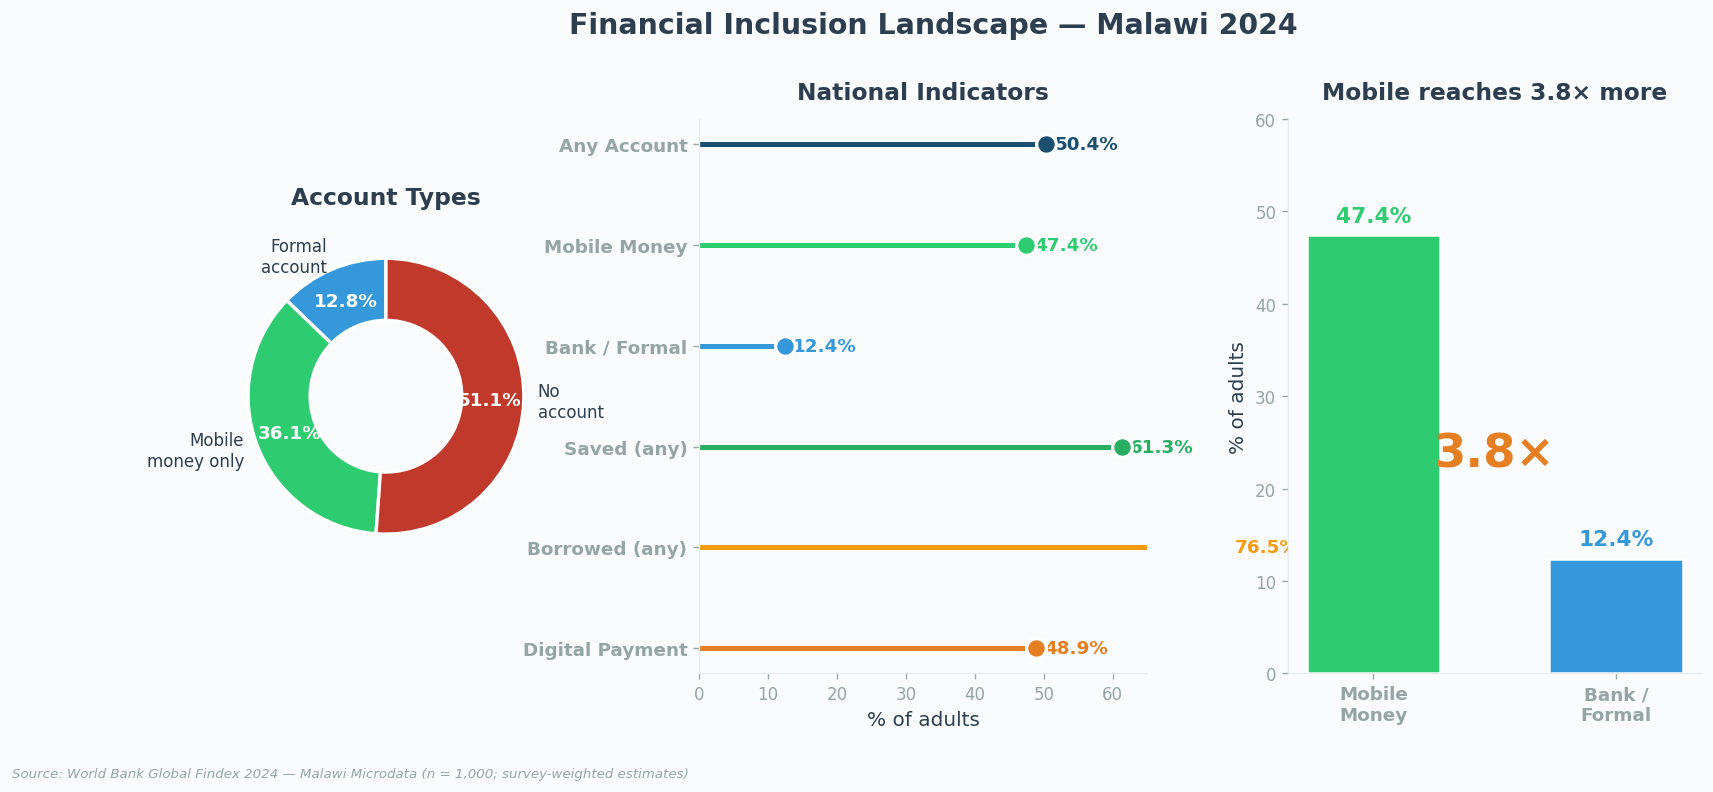

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# KEY FINDING 1: National Financial Inclusion Landscape
# ═══════════════════════════════════════════════════════════════════════════════

indicators = {
    "Any Account":        weighted_mean(df['account'],       df['wgt']) * 100,
    "Mobile Money":       weighted_mean(df['account_mob'],   df['wgt']) * 100,
    "Bank / Formal":      weighted_mean(df['account_fin'],   df['wgt']) * 100,
    "Saved (any)":        weighted_mean(df['saved'],         df['wgt']) * 100,
    "Borrowed (any)":     weighted_mean(df['borrowed'],      df['wgt']) * 100,
    "Digital Payment":    weighted_mean(df['anydigpayment'], df['wgt']) * 100,
}

# ─── KPI Cards ────────────────────────────────────────────────────────────
kpi_card_html([
    ("Any Account",     fmt_pct(indicators["Any Account"]),     "💳", COLORS['primary']),
    ("Mobile Money",    fmt_pct(indicators["Mobile Money"]),    "📱", COLORS['mobile']),
    ("Bank / Formal",   fmt_pct(indicators["Bank / Formal"]),   "🏦", COLORS['bank']),
    ("Digital Payment", fmt_pct(indicators["Digital Payment"]), "⚡", COLORS['accent']),
    ("Saved",           fmt_pct(indicators["Saved (any)"]),     "💰", COLORS['success']),
    ("Borrowed",        fmt_pct(indicators["Borrowed (any)"]),  "🤝", COLORS['warning']),
])

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — Account ownership triple (donut + waterfall + key indicators bar)
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 6))
gs = GridSpec(1, 3, width_ratios=[1, 1.3, 1.2], wspace=0.35)

# ── Panel 1: Account type donut ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
pct_formal = indicators["Bank / Formal"]
pct_mm_only = indicators["Mobile Money"] - pct_formal  # approximate mobile-only
pct_excluded = 100 - indicators["Any Account"]
sizes = [pct_formal, max(pct_mm_only, 0), pct_excluded]
labels = ['Formal\naccount', 'Mobile\nmoney only', 'No\naccount']
cols = [COLORS['bank'], COLORS['mobile'], COLORS['danger']]
wedges, texts, autotexts = ax1.pie(
    sizes, labels=labels, colors=cols, autopct='%1.1f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    textprops={'fontsize': 10})
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
ax1.set_title('Account Types', fontsize=14, fontweight='bold', pad=12)

# ── Panel 2: Key indicators lollipop ─────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ind_keys = list(indicators.keys())
ind_vals = list(indicators.values())
ind_cols = [COLORS['primary'], COLORS['mobile'], COLORS['bank'],
            COLORS['success'], COLORS['warning'], COLORS['accent']]
y_pos = np.arange(len(ind_keys))

for i, (k, v) in enumerate(zip(ind_keys, ind_vals)):
    ax2.plot([0, v], [i, i], color=ind_cols[i], linewidth=3, solid_capstyle='round')
    ax2.scatter(v, i, s=140, color=ind_cols[i], zorder=5, edgecolors='white', linewidth=2)
    ax2.text(v + 1.2, i, f'{v:.1f}%', va='center', fontsize=11,
             fontweight='bold', color=ind_cols[i])
ax2.set_yticks(y_pos)
ax2.set_yticklabels(ind_keys, fontsize=11, fontweight='bold')
ax2.set_xlim(0, 65)
ax2.set_xlabel('% of adults')
ax2.set_title('National Indicators', fontsize=14, fontweight='bold', pad=12)
ax2.invert_yaxis()

# ── Panel 3: Mobile vs Bank multiplier ───────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ratio = indicators["Mobile Money"] / max(indicators["Bank / Formal"], 0.1)
cats = ['Mobile\nMoney', 'Bank /\nFormal']
vals = [indicators["Mobile Money"], indicators["Bank / Formal"]]
bar_cols = [COLORS['mobile'], COLORS['bank']]
for i, (c, v, col) in enumerate(zip(cats, vals, bar_cols)):
    ax3.bar(i, v, width=0.55, color=col, edgecolor='white', linewidth=1.5)
    ax3.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold', color=col)
ax3.set_xticks([0, 1]); ax3.set_xticklabels(cats, fontsize=11, fontweight='bold')
ax3.set_ylabel('% of adults')
ax3.set_ylim(0, 60)
ax3.set_title(f'Mobile reaches {ratio:.1f}× more', fontsize=14, fontweight='bold', pad=12)

# annotation
ax3.annotate(f'{ratio:.1f}×', xy=(0.5, max(vals) / 2), fontsize=28,
             fontweight='bold', color=COLORS['accent'], ha='center', va='center')

fig.suptitle('Financial Inclusion Landscape — Malawi 2024',
             fontsize=17, fontweight='bold', y=1.03)
add_source_note(fig)
plt.savefig('../outputs/figures/exec_landscape.png', bbox_inches='tight', dpi=200)
plt.show()

---

## 📊 KEY FINDING 2: Demographic Disparities

### Account Ownership by Demographics

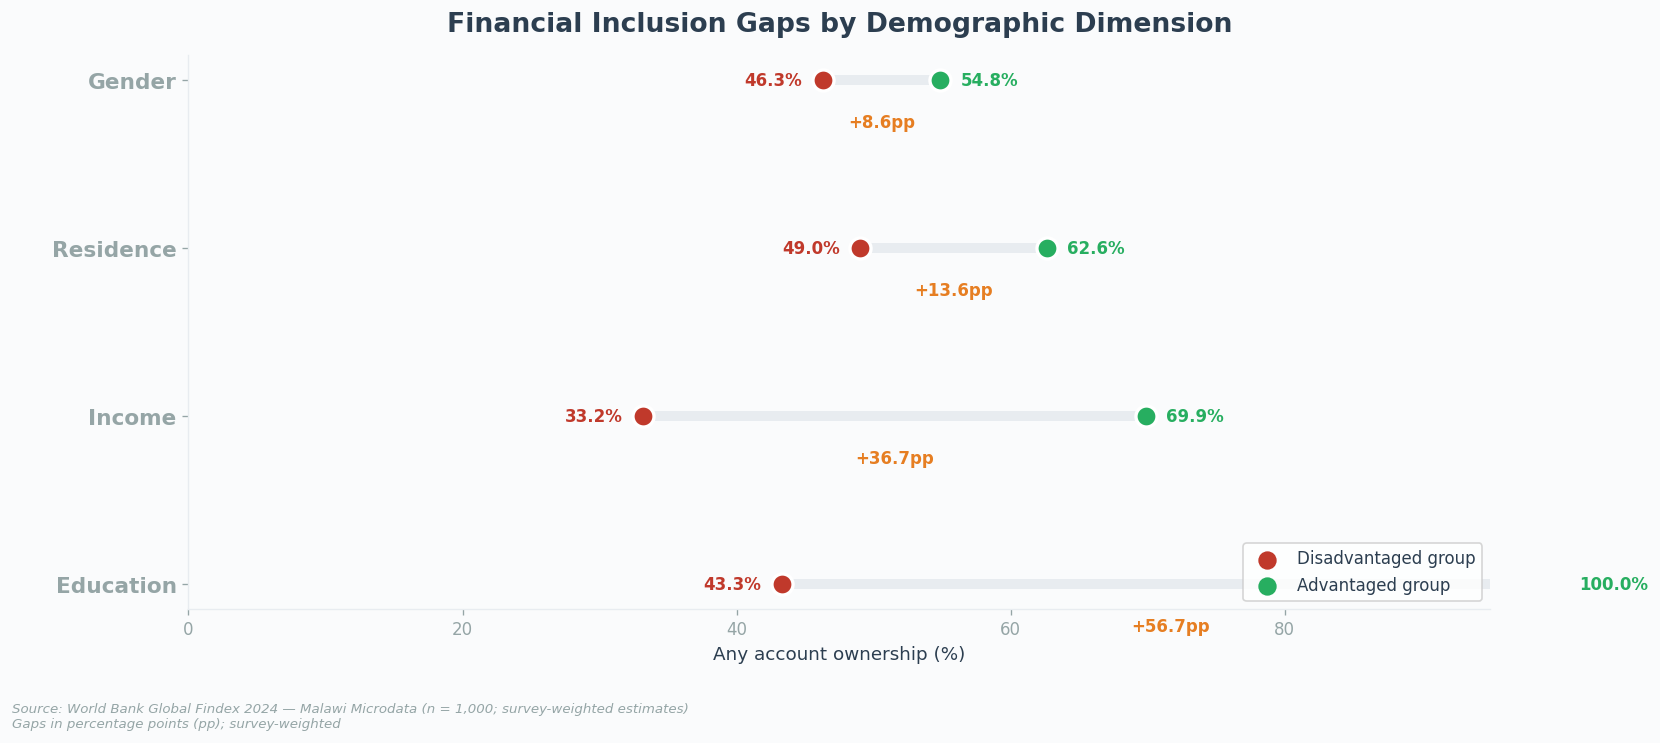

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# KEY FINDING 2: Demographic Disparities
# ═══════════════════════════════════════════════════════════════════════════════

# Compute rates
male_rate    = weighted_mean(df[df['female']==2]['account'], df[df['female']==2]['wgt']) * 100
female_rate  = weighted_mean(df[df['female']==1]['account'], df[df['female']==1]['wgt']) * 100
urban_rate   = weighted_mean(df[df['urbanicity']==2]['account'], df[df['urbanicity']==2]['wgt']) * 100
rural_rate   = weighted_mean(df[df['urbanicity']==1]['account'], df[df['urbanicity']==1]['wgt']) * 100
richest_rate = weighted_mean(df[df['inc_q']==5]['account'], df[df['inc_q']==5]['wgt']) * 100
poorest_rate = weighted_mean(df[df['inc_q']==1]['account'], df[df['inc_q']==1]['wgt']) * 100
tert_rate    = weighted_mean(df[df['educ']==3]['account'], df[df['educ']==3]['wgt']) * 100
prim_rate    = weighted_mean(df[df['educ']==1]['account'], df[df['educ']==1]['wgt']) * 100

gaps = {
    'Gender (M − F)':        male_rate - female_rate,
    'Residence (U − R)':     urban_rate - rural_rate,
    'Income (Q5 − Q1)':      richest_rate - poorest_rate,
    'Education (T − P)':     tert_rate - prim_rate,
}

# ─── KPI Cards ────────────────────────────────────────────────────────────
kpi_card_html([
    ("Gender Gap",     f"{gaps['Gender (M − F)']:+.1f}pp",    "♀️♂️", COLORS['danger']),
    ("Urban–Rural Gap",f"{gaps['Residence (U − R)']:+.1f}pp", "🏘️", COLORS['accent']),
    ("Income Gap",     f"{gaps['Income (Q5 − Q1)']:+.1f}pp",  "💰", COLORS['warning']),
    ("Education Gap",  f"{gaps['Education (T − P)']:+.1f}pp", "🎓", COLORS['secondary']),
])

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — Dumbbell chart for demographic gaps
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))

pairs = [
    ('Gender',    female_rate, male_rate,    'Female', 'Male'),
    ('Residence', rural_rate,  urban_rate,   'Rural',  'Urban'),
    ('Income',    poorest_rate, richest_rate, 'Q1 (poorest)', 'Q5 (richest)'),
    ('Education', prim_rate,   tert_rate,    'Primary', 'Tertiary'),
]

y_pos = np.arange(len(pairs))
for i, (label, low, high, low_lbl, high_lbl) in enumerate(pairs):
    ax.plot([low, high], [i, i], color=COLORS['grid'], linewidth=6, solid_capstyle='round', zorder=1)
    ax.scatter(low, i, s=160, color=COLORS['danger'], zorder=5, edgecolors='white', linewidth=2)
    ax.scatter(high, i, s=160, color=COLORS['success'], zorder=5, edgecolors='white', linewidth=2)
    ax.text(low - 1.5, i, f'{low:.1f}%', ha='right', va='center', fontsize=10,
            fontweight='bold', color=COLORS['danger'])
    ax.text(high + 1.5, i, f'{high:.1f}%', ha='left', va='center', fontsize=10,
            fontweight='bold', color=COLORS['success'])
    gap = high - low
    ax.text((low + high) / 2, i + 0.28, f'{gap:+.1f}pp', ha='center', fontsize=10,
            fontweight='bold', color=COLORS['accent'])

ax.set_yticks(y_pos)
ax.set_yticklabels([p[0] for p in pairs], fontsize=13, fontweight='bold')
ax.set_xlabel('Any account ownership (%)', fontsize=11)
ax.set_xlim(0, 95)
ax.invert_yaxis()

# legend
ax.scatter([], [], s=100, color=COLORS['danger'], label='Disadvantaged group')
ax.scatter([], [], s=100, color=COLORS['success'], label='Advantaged group')
ax.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white')

ax.set_title('Financial Inclusion Gaps by Demographic Dimension',
             fontsize=16, fontweight='bold', pad=14)
add_source_note(fig, 'Gaps in percentage points (pp); survey-weighted')
plt.savefig('../outputs/figures/exec_gaps.png', bbox_inches='tight', dpi=200)
plt.show()

---

## 📊 KEY FINDING 3: Barriers to Financial Inclusion

### Top Reasons for Financial Exclusion

,Prevalence (%)
Barrier,
Lack of money,80.1
Lack documentation,34.6
Security worries,28.5
Too expensive,27.1
Agents too far,14.7


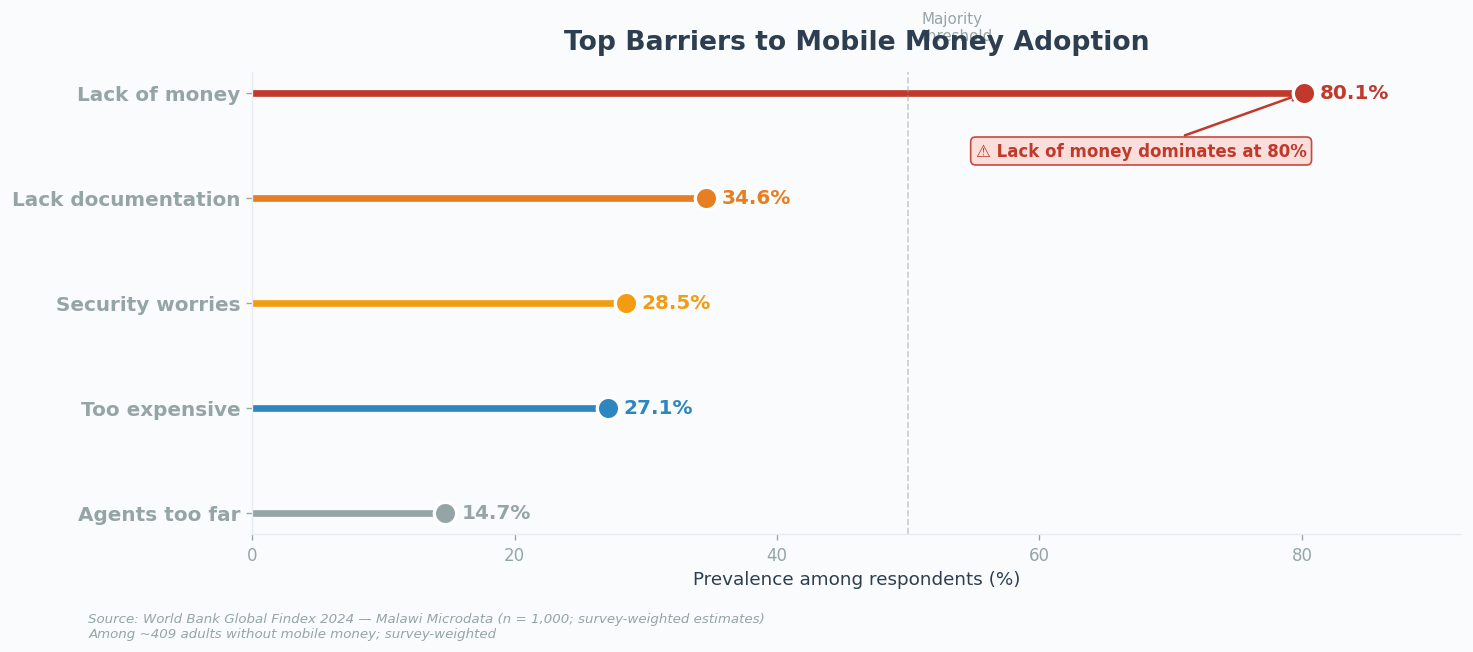

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# KEY FINDING 3: Barriers to Financial Inclusion
# ═══════════════════════════════════════════════════════════════════════════════

mm_barriers = {
    'fin14d': 'Lack of money', 'fin14b': 'Too expensive', 'fin14a': 'Agents too far',
    'fin14c': 'Lack documentation', 'fin14e': 'Security worries',
}

barrier_prevalence = {}
for var, label in mm_barriers.items():
    valid = df[var].isin([1, 2])
    if valid.sum() > 0:
        barrier_prevalence[label] = weighted_mean(df.loc[valid, var].eq(1), df.loc[valid, 'wgt']) * 100

barrier_prevalence = dict(sorted(barrier_prevalence.items(), key=lambda x: x[1], reverse=True))

# ─── Styled table ─────────────────────────────────────────────────────────
bdf = pd.DataFrame([{'Barrier': k, 'Prevalence (%)': v} for k, v in barrier_prevalence.items()])
display(styled_table(bdf.set_index('Barrier'),
                     '🚧 Barriers to Mobile Money Adoption (Among Non-Users, ~409 respondents)',
                     bar_col='Prevalence (%)'))

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — Horizontal lollipop
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 5))
barriers = list(reversed(list(barrier_prevalence.keys())))
values   = list(reversed(list(barrier_prevalence.values())))
pal = [COLORS['muted'], COLORS['secondary'], COLORS['warning'], COLORS['accent'], COLORS['danger']]

for i, (b, v) in enumerate(zip(barriers, values)):
    ax.plot([0, v], [i, i], color=pal[i], linewidth=4, solid_capstyle='round')
    ax.scatter(v, i, s=180, color=pal[i], zorder=5, edgecolors='white', linewidth=2)
    ax.text(v + 1.2, i, f'{v:.1f}%', va='center', fontsize=12, fontweight='bold', color=pal[i])

ax.set_yticks(range(len(barriers)))
ax.set_yticklabels(barriers, fontsize=12, fontweight='bold')
ax.set_xlim(0, max(values) + 12)
ax.set_xlabel('Prevalence among respondents (%)', fontsize=11)
ax.axvline(50, ls='--', color=COLORS['muted'], alpha=0.5, lw=1)
ax.text(51, len(barriers) - 0.5, 'Majority\nthreshold', fontsize=9, color=COLORS['muted'])

# highlight top
top_b = list(barrier_prevalence.keys())[0]
top_v = list(barrier_prevalence.values())[0]
ax.annotate(f'⚠ {top_b} dominates at {top_v:.0f}%',
            xy=(top_v, len(barriers) - 1),
            xytext=(top_v - 25, len(barriers) - 1.6),
            fontsize=10, fontweight='bold', color=COLORS['danger'],
            arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', fc='#FADBD8', ec=COLORS['danger'], alpha=0.9))

ax.set_title('Top Barriers to Mobile Money Adoption',
             fontsize=16, fontweight='bold', pad=14)
add_source_note(fig, 'Among ~409 adults without mobile money; survey-weighted')
plt.savefig('../outputs/figures/exec_barriers.png', bbox_inches='tight', dpi=200)
plt.show()

---

## 📊 KEY FINDING 4: Statistical Impact Analysis

### Which Barriers Matter Most? (Logistic Regression Results)

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# KEY FINDING 4: Regression Summary (qualitative — see NB 04 for full tables)
# ═══════════════════════════════════════════════════════════════════════════════

summary_rows = [
    ("Education (per level ↑)",  "↑ Strong positive",  "Higher education → much higher inclusion"),
    ("Income (per quintile ↑)",  "↑ Strong positive",  "Wealthier → more accounts"),
    ("Female (vs Male)",         "↓ Moderate negative", "Women face ~6 pp disadvantage"),
    ("Lack of money barrier",    "↓ Strong negative",   "Highest prevalence + largest effect"),
    ("Cost barrier",             "— Mixed / complex",   "Selection bias complicates interpretation"),
    ("Documentation barrier",    "↓ Moderate negative",  "KYC requirements block entry"),
    ("Trust / security barrier", "↓ Moderate negative",  "Safety concerns reduce uptake"),
    ("Distance barrier",         "↑ Paradoxical*",       "*Selection bias: see NB 04 caveat"),
]

tbl = pd.DataFrame(summary_rows, columns=['Predictor', 'Direction', 'Interpretation'])
display(styled_table(tbl.set_index('Predictor'),
                     '📐 Logistic Regression Summary (Survey-Weighted, Dual-Outcome)'))

# ─── Caveat card ──────────────────────────────────────────────────────────
display(HTML(f"""
<div style="max-width:800px;margin:12px auto;padding:14px 20px;border-radius:10px;
    background:#FEF9E7;border-left:4px solid {COLORS['warning']};font-size:12px;">
    ⚠️ <b>Selection bias caveat:</b> Barrier questions are only asked to already-excluded individuals.
    Coefficients represent associations <em>within the at-risk population</em>, not causal effects.
    Distance shows a paradoxical positive OR due to this artefact — see <b>Notebook 04</b> for full details.
</div>
"""))

display(HTML(f"""
<div style="max-width:800px;margin:12px auto;padding:14px 20px;border-radius:10px;
    background:white;border-left:4px solid {COLORS['primary']};font-size:12px;
    box-shadow:0 1px 8px rgba(0,0,0,0.05);">
    💡 <b>Key insight:</b> After controlling for demographics, <span style="color:{COLORS['danger']};font-weight:bold;">
    LACK OF MONEY</span> is the dominant barrier by both prevalence (~36%) and effect size.
    <b>Education</b> and <b>income</b> are the strongest enablers.
    The <b>gender gap persists</b> (~6 pp) after controls.
</div>
"""))

,Direction,Interpretation
Predictor,,
Education (per level ↑),↑ Strong positive,Higher education → much higher inclusion
Income (per quintile ↑),↑ Strong positive,Wealthier → more accounts
Female (vs Male),↓ Moderate negative,Women face ~6 pp disadvantage
Lack of money barrier,↓ Strong negative,Highest prevalence + largest effect
Cost barrier,— Mixed / complex,Selection bias complicates interpretation
Documentation barrier,↓ Moderate negative,KYC requirements block entry
Trust / security barrier,↓ Moderate negative,Safety concerns reduce uptake
Distance barrier,↑ Paradoxical*,*Selection bias: see NB 04 caveat


---

## 🎯 POLICY RECOMMENDATIONS

### Evidence-Based Intervention Strategy

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# POLICY RECOMMENDATIONS — Evidence-Based Roadmap
# ═══════════════════════════════════════════════════════════════════════════════

roadmap = [
    ('Immediate', '2026–27', COLORS['danger'], [
        ("Link social protection to mobile accounts", "~36% Lack of Money"),
        ("Zero-fee basic mobile savings products", "Affordability"),
        ("Tiered KYC — basic account with national ID", "~15% Documentation"),
        ("Cap / subsidise basic transaction fees", "~12% Cost"),
    ]),
    ('Medium-term', '2027–29', COLORS['accent'], [
        ("Consumer-protection for mobile wallets", "~13% Trust / Security"),
        ("Agent-network expansion in underserved areas", "~6% Distance"),
        ("Recruit & train female MM agents", "Gender gap"),
        ("Partner with VSLAs for outreach", "Women's inclusion"),
    ]),
    ('Structural', 'Ongoing', COLORS['secondary'], [
        ("Invest in rural mobile-network infra", "Access"),
        ("Digitise government-to-person payments", "Scale"),
        ("Promote provider interoperability", "Competition"),
        ("Annual inclusion monitoring surveys", "Accountability"),
    ]),
]

cards_html = ""
for phase, timeline, color, actions in roadmap:
    items = ''.join(f'<li>{a} <span style="color:{COLORS["muted"]};font-size:12px;">({t})</span></li>'
                    for a, t in actions)
    cards_html += f"""<div style="border-left:4px solid {color};background:white;
        border-radius:10px;padding:14px 18px;margin:8px 0;box-shadow:0 1px 8px rgba(0,0,0,0.05);">
        <div style="display:flex;justify-content:space-between;align-items:center;">
            <span style="font-weight:800;color:{color};font-size:14px;">📌 {phase}</span>
            <span style="font-size:12px;color:{COLORS['muted']};">⏱️ {timeline}</span>
        </div>
        <ul style="font-size:12px;padding-left:18px;margin:6px 0 0;">{items}</ul>
    </div>"""

display(HTML(f"""<div style="max-width:850px;margin:auto;">
    <h3 style="color:{COLORS['primary']};text-align:center;margin-bottom:12px;">
    🎯 Evidence-Based Policy Roadmap</h3>
    {cards_html}
    <div style="margin-top:12px;padding:10px 14px;background:#F8F9FA;border-radius:8px;font-size:12px;
        color:{COLORS['muted']};text-align:center;">
        ⚠️ Impact projections not included — cross-sectional data cannot predict dynamic effects.
        Rigorous impact evaluation (RCT / quasi-experimental) is recommended post-intervention.
    </div>
</div>"""))

---

## Summary: The Complete Story

### What We Found

1. **Mobile money is the inclusion engine** — reaching ~47% of adults vs. ~12% for formal bank accounts.
2. **Lack of money is the dominant barrier** — reported by ~36% of all respondents (composite indicator) and the strongest predictor in weighted logistic regression.
3. **Education and income are the strongest enablers** — steep gradients confirm that human-capital investment and poverty reduction are prerequisites for inclusion.
4. **Women face a persistent ~6 pp disadvantage** in formal accounts after controlling for income, education, and barriers.
5. **Barrier data carries selection bias** — questions are only asked to already-excluded individuals, so regression results represent associations within the at-risk population, not causal effects.

### Why It Matters

Financial inclusion enables:
- **Economic resilience:** Safe savings for emergencies
- **Productive investment:** Credit for business growth
- **Efficiency gains:** Digital payments save time and money
- **Social equity:** Reduces gender and geographic disparities
- **Development progress:** Contributes to SDG 8.10 targets

### Analytical Strengths

- Survey-weighted logistic regression ensures nationally representative inference
- Dual-outcome framework (formal account vs. any account) reveals different barrier dynamics
- ROC analysis with threshold optimisation addresses class imbalance
- All variable labels verified against the official Global Findex 2024 codebook

### Limitations

- Cross-sectional data — no causal identification
- Small sample (n ≈ 1,000) limits subgroup precision
- Bank barriers (fin11a–f) have zero valid responses; all barrier data from mobile money questions only
- Low pseudo R² indicates substantial unexplained variation

---

## Navigate to Detailed Analysis

- **[Notebook 01: Data Import & Checks](01_data_import_and_checks.ipynb)** — Data validation
- **[Notebook 02: Descriptive Analysis](02_descriptive_analysis.ipynb)** — National statistics
- **[Notebook 03: Barriers Analysis](03_barriers_analysis.ipynb)** — Barrier identification
- **[Notebook 04: Policy Analysis](04_from_barriers_to_policy.ipynb)** — Regression & recommendations

---

**Data Source:** World Bank Global Findex Database 2024 — Malawi Microdata  
**Author:** Brian Thuwala | thuwalabrian@gmail.com  
**Codebook:** codebook_microdata_2025.pdf